<a href="https://colab.research.google.com/github/Rohil121/bharat-portfolio-lab/blob/main/notebooks/01_portfolio_mvp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bharat Portfolio Lab — Portfolio Analytics MVP

## Project objective

Build and deploy an explainable Indian equity portfolio-analysis platform that:

- analyses a flagship Indian equity portfolio,
- compares it against a suitable Indian benchmark,
- measures return, risk, diversification and drawdowns,
- tests a rules-based portfolio strategy, and
- progressively adds forecasting, optimisation and stress-testing models.

## Version

**v0.1 — Preliminary Portfolio Analytics Model**

## Tools

Python | Google Colab | GitHub | Streamlit


## 1. Environment Setup

This section installs and imports the Python libraries required for the initial portfolio analytics model.


In [1]:
# Install the market-data library
%pip install -q yfinance==1.5.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 3.1 MB/s eta 0:00:00


In [2]:
# Core Python libraries
import sys
from importlib.metadata import version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Reproducibility and display settings
np.random.seed(42)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Confirm the environment
print("Environment setup complete.")
print(f"Python version: {sys.version.split()[0]}")
print(f"pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"yfinance version: {version('yfinance')}")

Environment setup complete.
Python version: 3.12.13
pandas version: 2.2.2
NumPy version: 2.0.2
yfinance version: 1.5.1


## 2. Flagship Portfolio Definition

### India 10 Adaptive Barbell Portfolio

The flagship portfolio combines two complementary groups:

- **5 Resilient Compounders:** companies selected for business quality, earnings stability and relatively defensive characteristics.
- **5 Growth Leaders:** companies representing structural Indian growth themes such as digitalisation, infrastructure, manufacturing, defence and consumption.

For the preliminary v0.1 model, the portfolio uses fixed stocks and equal 10% weights.

In later versions, the stocks will be selected systematically using quality, momentum, volatility and diversification scores. The portfolio is an academic case study and not an investment recommendation.

In [3]:
# India 10 Adaptive Barbell Portfolio — preliminary v0.1 portfolio

portfolio = pd.DataFrame(
    {
        "Company": [
            # Resilient Compounders
            "HDFC Bank",
            "Tata Consultancy Services",
            "Hindustan Unilever",
            "Sun Pharmaceutical Industries",
            "Power Grid Corporation of India",

            # Growth Leaders
            "Bharti Airtel",
            "Larsen & Toubro",
            "Mahindra & Mahindra",
            "Bharat Electronics",
            "Trent",
        ],

        "Ticker": [
            "HDFCBANK.NS",
            "TCS.NS",
            "HINDUNILVR.NS",
            "SUNPHARMA.NS",
            "POWERGRID.NS",
            "BHARTIARTL.NS",
            "LT.NS",
            "M&M.NS",
            "BEL.NS",
            "TRENT.NS",
        ],

        "Sector": [
            "Financial Services",
            "Information Technology",
            "Consumer Staples",
            "Healthcare",
            "Utilities",
            "Telecommunication",
            "Industrials",
            "Automobile",
            "Defence Electronics",
            "Consumer Retail",
        ],

        "Strategy Bucket": [
            "Resilient Compounder",
            "Resilient Compounder",
            "Resilient Compounder",
            "Resilient Compounder",
            "Resilient Compounder",
            "Growth Leader",
            "Growth Leader",
            "Growth Leader",
            "Growth Leader",
            "Growth Leader",
        ],

        "Preliminary Rationale": [
            "Large private-sector bank with a diversified lending franchise",
            "Established technology-services company with global revenue exposure",
            "Consumer-staples company with defensive demand characteristics",
            "Large pharmaceutical company providing healthcare-sector diversification",
            "Regulated power-transmission business with relatively stable operations",
            "Exposure to India's telecom and digital-consumption growth",
            "Exposure to infrastructure and capital-expenditure activity",
            "Exposure to automobiles, utility vehicles and domestic manufacturing",
            "Exposure to defence electronics and domestic defence capital expenditure",
            "Exposure to organised retail and discretionary-consumption growth",
        ],
    }
)

# Equal weights for the preliminary version
portfolio["Weight"] = 1 / len(portfolio)

# Project parameters
BENCHMARK_TICKER = "^NSEI"
BENCHMARK_NAME = "Nifty 50"

START_DATE = "2021-04-01"

# Use market data available up to the notebook execution date
ANALYSIS_END_DATE = pd.Timestamp.today().normalize()
DOWNLOAD_END_DATE = ANALYSIS_END_DATE + pd.Timedelta(days=1)

INITIAL_CAPITAL = 1_000_000  # ₹10 lakh

# Validation checks
assert len(portfolio) == 10, "The flagship portfolio must contain exactly 10 stocks."
assert portfolio["Ticker"].is_unique, "Duplicate ticker detected."
assert np.isclose(portfolio["Weight"].sum(), 1.0), \
    "Portfolio weights must sum to 100%."
assert portfolio["Strategy Bucket"].value_counts().to_dict() == {
    "Resilient Compounder": 5,
    "Growth Leader": 5
}, "The portfolio must contain five stocks in each strategy bucket."

# Presentation columns
portfolio["Weight (%)"] = portfolio["Weight"] * 100
portfolio["Initial Allocation (₹)"] = (
    portfolio["Weight"] * INITIAL_CAPITAL
)

print("India 10 Adaptive Barbell Portfolio")
print("-" * 45)
print(f"Number of holdings: {len(portfolio)}")
print(f"Total portfolio weight: {portfolio['Weight'].sum():.2%}")
print(f"Resilient Compounders: {(portfolio['Strategy Bucket'] == 'Resilient Compounder').sum()}")
print(f"Growth Leaders: {(portfolio['Strategy Bucket'] == 'Growth Leader').sum()}")
print(f"Benchmark: {BENCHMARK_NAME}")
print(f"Analysis begins: {START_DATE}")
print(f"Initial capital: ₹{INITIAL_CAPITAL:,.0f}")

portfolio[
    [
        "Company",
        "Ticker",
        "Sector",
        "Strategy Bucket",
        "Weight (%)",
        "Initial Allocation (₹)",
        "Preliminary Rationale",
    ]
]

India 10 Adaptive Barbell Portfolio
---------------------------------------------
Number of holdings: 10
Total portfolio weight: 100.00%
Resilient Compounders: 5
Growth Leaders: 5
Benchmark: Nifty 50
Analysis begins: 2021-04-01
Initial capital: ₹1,000,000


,Company,Ticker,Sector,Strategy Bucket,Weight (%),Initial Allocation (₹),Preliminary Rationale
0,HDFC Bank,HDFCBANK.NS,Financial Services,Resilient Compounder,10.0000,"100,000.0000",Large private-sector bank with a diversified l...
1,Tata Consultancy Services,TCS.NS,Information Technology,Resilient Compounder,10.0000,"100,000.0000",Established technology-services company with g...
2,Hindustan Unilever,HINDUNILVR.NS,Consumer Staples,Resilient Compounder,10.0000,"100,000.0000",Consumer-staples company with defensive demand...
3,Sun Pharmaceutical Industries,SUNPHARMA.NS,Healthcare,Resilient Compounder,10.0000,"100,000.0000",Large pharmaceutical company providing healthc...
4,Power Grid Corporation of India,POWERGRID.NS,Utilities,Resilient Compounder,10.0000,"100,000.0000",Regulated power-transmission business with rel...
5,Bharti Airtel,BHARTIARTL.NS,Telecommunication,Growth Leader,10.0000,"100,000.0000",Exposure to India's telecom and digital-consum...
6,Larsen & Toubro,LT.NS,Industrials,Growth Leader,10.0000,"100,000.0000",Exposure to infrastructure and capital-expendi...
7,Mahindra & Mahindra,M&M.NS,Automobile,Growth Leader,10.0000,"100,000.0000","Exposure to automobiles, utility vehicles and ..."
8,Bharat Electronics,BEL.NS,Defence Electronics,Growth Leader,10.0000,"100,000.0000",Exposure to defence electronics and domestic d...
9,Trent,TRENT.NS,Consumer Retail,Growth Leader,10.0000,"100,000.0000",Exposure to organised retail and discretionary...


## 3. Historical Market Data

Adjusted daily closing prices are downloaded for all portfolio securities and the Nifty 50 benchmark.

Adjusted prices are used because they account for events such as stock splits and dividends, making historical-return calculations more meaningful.

The data is validated before any portfolio metrics are calculated.

In [4]:
# Download adjusted historical prices

portfolio_tickers = portfolio["Ticker"].tolist()
all_tickers = portfolio_tickers + [BENCHMARK_TICKER]

raw_market_data = yf.download(
    tickers=all_tickers,
    start=START_DATE,
    end=DOWNLOAD_END_DATE.strftime("%Y-%m-%d"),
    auto_adjust=True,
    progress=False,
    threads=True,
    group_by="column",
)

# Extract closing prices
if isinstance(raw_market_data.columns, pd.MultiIndex):
    close_prices = raw_market_data["Close"].copy()
else:
    close_prices = raw_market_data[["Close"]].copy()
    close_prices.columns = all_tickers

# Ensure consistent column order
close_prices = close_prices.reindex(columns=all_tickers)
close_prices = close_prices.sort_index()

# Inspect missing observations before cleaning
missing_before = close_prices.isna().sum()

# Fill only short data gaps, then remove incomplete rows
close_prices = close_prices.ffill(limit=3).dropna()

# Separate portfolio and benchmark prices
stock_prices = close_prices[portfolio_tickers].copy()
benchmark_prices = close_prices[[BENCHMARK_TICKER]].copy()
benchmark_prices.columns = [BENCHMARK_NAME]

# Validation checks
assert not stock_prices.empty, "No stock-price data was downloaded."
assert not benchmark_prices.empty, "No benchmark data was downloaded."
assert stock_prices.shape[1] == 10, "Data is not available for all 10 stocks."
assert stock_prices.isna().sum().sum() == 0, "Missing stock prices remain."
assert benchmark_prices.isna().sum().sum() == 0, \
    "Missing benchmark prices remain."

print("Historical market data downloaded successfully.")
print("-" * 50)
print(f"First observation: {close_prices.index.min().date()}")
print(f"Latest observation: {close_prices.index.max().date()}")
print(f"Trading observations: {len(close_prices):,}")
print(f"Portfolio securities: {stock_prices.shape[1]}")
print(f"Benchmark: {BENCHMARK_NAME}")

print("\nMissing observations before cleaning:")
display(missing_before.to_frame("Missing Days"))

print("\nLatest adjusted prices:")
display(close_prices.tail())

Historical market data downloaded successfully.
--------------------------------------------------
First observation: 2021-04-01
Latest observation: 2026-07-30
Trading observations: 1,320
Portfolio securities: 10
Benchmark: Nifty 50

Missing observations before cleaning:


,Missing Days
Ticker,
HDFCBANK.NS,0
TCS.NS,0
HINDUNILVR.NS,0
SUNPHARMA.NS,0
POWERGRID.NS,0
BHARTIARTL.NS,0
LT.NS,0
M&M.NS,0
BEL.NS,0



Latest adjusted prices:


Ticker,HDFCBANK.NS,TCS.NS,HINDUNILVR.NS,SUNPHARMA.NS,POWERGRID.NS,BHARTIARTL.NS,LT.NS,M&M.NS,BEL.NS,TRENT.NS,^NSEI
Date,,,,,,,,,,,
2026-07-24,742.8000,"2,254.3000","2,145.0000","1,941.1000",288.2000,"1,898.2000","3,785.6001","3,161.3999",405.0000,"2,890.5000","23,767.4492"
2026-07-27,739.5500,"2,295.6001","2,174.6001","1,973.7000",288.8500,"1,905.3000","3,806.0000","3,238.6001",407.1500,"2,938.3000","23,995.9492"
2026-07-28,735.4000,"2,398.0000","2,022.7000","1,976.7000",285.3000,"1,901.8000","3,832.0000","3,271.2000",389.0000,"2,930.7000","23,985.3496"
2026-07-29,748.2000,"2,446.6001","2,117.8000","1,989.9000",282.8500,"1,950.2000","3,931.3999","3,221.8000",387.5500,"3,005.2000","24,250.1992"
2026-07-30,751.7500,"2,445.8000","2,104.8000","2,013.4000",285.8500,"1,951.7000","3,933.5000","3,284.3999",385.1000,"2,987.3999","24,276.0996"


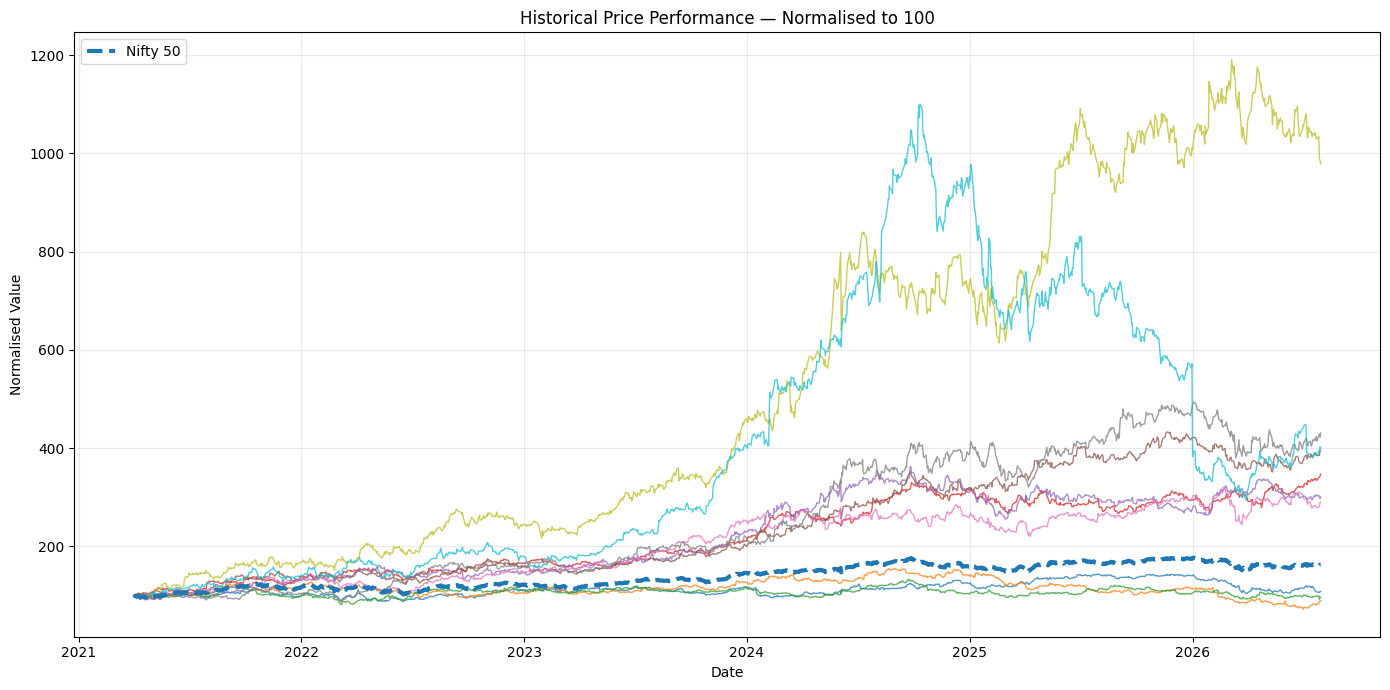

In [5]:
# Normalise all prices to 100 to compare their historical paths

normalised_prices = close_prices.div(close_prices.iloc[0]).mul(100)

plt.figure(figsize=(14, 7))

for ticker in portfolio_tickers:
    plt.plot(
        normalised_prices.index,
        normalised_prices[ticker],
        linewidth=1,
        alpha=0.75,
    )

plt.plot(
    normalised_prices.index,
    normalised_prices[BENCHMARK_TICKER],
    linewidth=3,
    linestyle="--",
    label=BENCHMARK_NAME,
)

plt.title("Historical Price Performance — Normalised to 100")
plt.xlabel("Date")
plt.ylabel("Normalised Value")
plt.legend(loc="upper left", ncol=2)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Preliminary Portfolio Performance

The preliminary model assumes that ₹10,00,000 is invested on the first available trading date.

The flagship portfolio allocates 10% to each of the 10 securities. The same initial amount is separately invested in the Nifty 50 benchmark.

Version v0.1 uses a buy-and-hold approach without rebalancing, transaction costs or taxes. These assumptions will be improved in later versions.

In [6]:
# Calculate the number of shares purchased on the initial date

initial_date = stock_prices.index[0]
initial_stock_prices = stock_prices.loc[initial_date]

weights = portfolio.set_index("Ticker")["Weight"].reindex(portfolio_tickers)
initial_allocations = weights * INITIAL_CAPITAL

# Fractional shares are allowed in this preliminary academic model
shares_purchased = initial_allocations / initial_stock_prices

# Daily value of each holding
holding_values = stock_prices.mul(shares_purchased, axis=1)

# Total flagship portfolio value
portfolio_value = holding_values.sum(axis=1)
portfolio_value.name = "India 10 Portfolio"

# Benchmark investment
initial_benchmark_price = benchmark_prices.iloc[0, 0]
benchmark_units = INITIAL_CAPITAL / initial_benchmark_price

benchmark_value = benchmark_prices.iloc[:, 0] * benchmark_units
benchmark_value.name = BENCHMARK_NAME

# Combine both value series
performance_values = pd.concat(
    [portfolio_value, benchmark_value],
    axis=1,
).dropna()

# Convert values into cumulative returns
cumulative_returns = (
    performance_values.div(performance_values.iloc[0]) - 1
)

# Validation checks
assert np.isclose(portfolio_value.iloc[0], INITIAL_CAPITAL), \
    "Initial portfolio value does not equal the starting capital."

assert np.isclose(benchmark_value.iloc[0], INITIAL_CAPITAL), \
    "Initial benchmark value does not equal the starting capital."

assert performance_values.isna().sum().sum() == 0, \
    "Missing values remain in the performance series."

print("Preliminary investment simulation completed.")
print("-" * 50)
print(f"Investment date: {initial_date.date()}")
print(f"Initial capital: ₹{INITIAL_CAPITAL:,.0f}")
print(f"Initial portfolio value: ₹{portfolio_value.iloc[0]:,.0f}")
print(f"Latest portfolio value: ₹{portfolio_value.iloc[-1]:,.0f}")
print(f"Latest benchmark value: ₹{benchmark_value.iloc[-1]:,.0f}")

print("\nInitial portfolio positions:")

initial_positions = pd.DataFrame(
    {
        "Company": portfolio.set_index("Ticker")
                            .reindex(portfolio_tickers)["Company"],
        "Initial Price (₹)": initial_stock_prices,
        "Initial Allocation (₹)": initial_allocations,
        "Shares Purchased": shares_purchased,
        "Latest Value (₹)": holding_values.iloc[-1],
    }
)

initial_positions["Current Weight (%)"] = (
    initial_positions["Latest Value (₹)"]
    / initial_positions["Latest Value (₹)"].sum()
    * 100
)

display(initial_positions)

Preliminary investment simulation completed.
--------------------------------------------------
Investment date: 2021-04-01
Initial capital: ₹1,000,000
Initial portfolio value: ₹1,000,000
Latest portfolio value: ₹3,436,930
Latest benchmark value: ₹1,632,846

Initial portfolio positions:


,Company,Initial Price (₹),Initial Allocation (₹),Shares Purchased,Latest Value (₹),Current Weight (%)
Ticker,,,,,,
HDFCBANK.NS,HDFC Bank,692.6507,"100,000.0000",144.3729,"108,532.3388",3.1578
TCS.NS,Tata Consultancy Services,"2,730.0894","100,000.0000",36.6288,"89,586.8131",2.6066
HINDUNILVR.NS,Hindustan Unilever,"2,184.0107","100,000.0000",45.7873,"96,373.1546",2.8040
SUNPHARMA.NS,Sun Pharmaceutical Industries,579.7927,"100,000.0000",172.4754,"347,262.0368",10.1038
POWERGRID.NS,Power Grid Corporation of India,95.0850,"100,000.0000","1,051.6909","300,625.8376",8.7469
BHARTIARTL.NS,Bharti Airtel,493.4187,"100,000.0000",202.6676,"395,546.4085",11.5087
LT.NS,Larsen & Toubro,"1,357.5824","100,000.0000",73.6604,"289,743.0025",8.4303
M&M.NS,Mahindra & Mahindra,762.4410,"100,000.0000",131.1577,"430,774.3147",12.5337
BEL.NS,Bharat Electronics,39.3515,"100,000.0000","2,541.1974","978,615.1238",28.4735


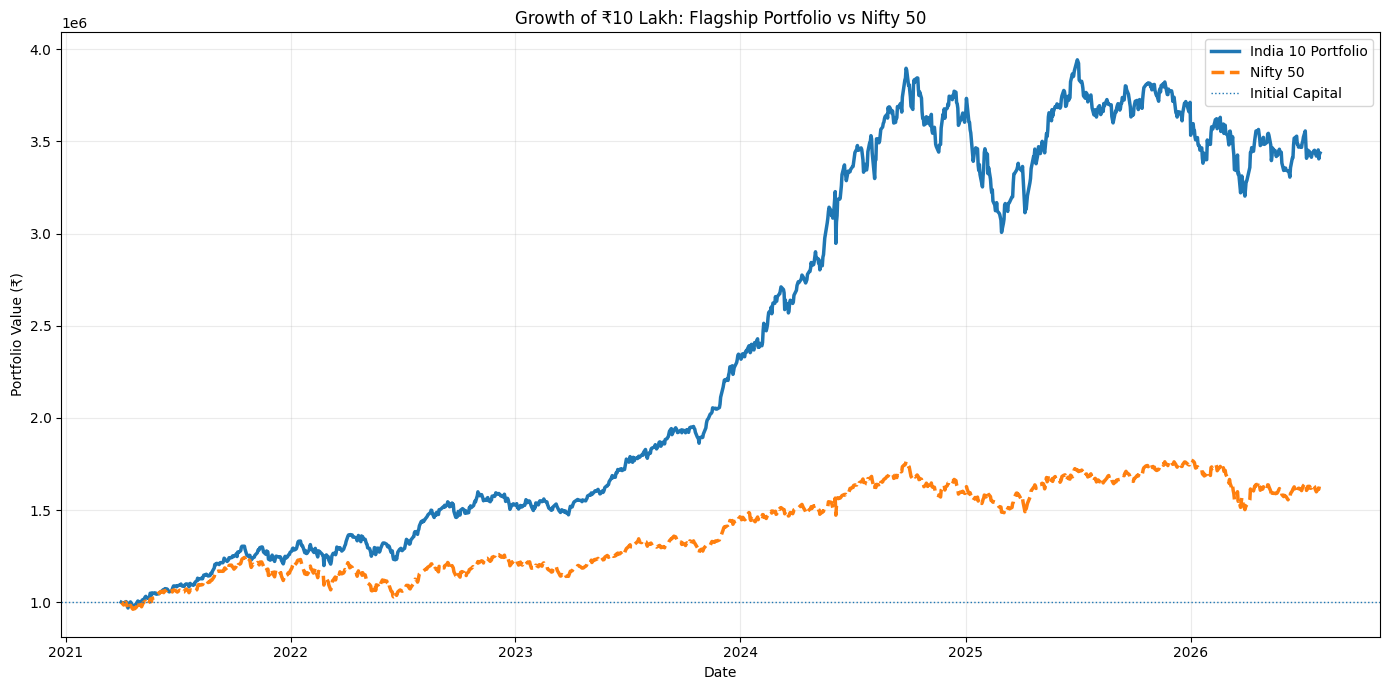

In [7]:
# Compare the flagship portfolio with the Nifty 50

plt.figure(figsize=(14, 7))

plt.plot(
    performance_values.index,
    performance_values["India 10 Portfolio"],
    linewidth=2.5,
    label="India 10 Portfolio",
)

plt.plot(
    performance_values.index,
    performance_values[BENCHMARK_NAME],
    linewidth=2.5,
    linestyle="--",
    label=BENCHMARK_NAME,
)

plt.axhline(
    INITIAL_CAPITAL,
    linewidth=1,
    linestyle=":",
    label="Initial Capital",
)

plt.title("Growth of ₹10 Lakh: Flagship Portfolio vs Nifty 50")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (₹)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [8]:
# Preliminary cumulative-return summary

portfolio_total_return = cumulative_returns[
    "India 10 Portfolio"
].iloc[-1]

benchmark_total_return = cumulative_returns[
    BENCHMARK_NAME
].iloc[-1]

excess_return = portfolio_total_return - benchmark_total_return

print("Preliminary Performance Summary")
print("-" * 40)
print(f"Portfolio total return: {portfolio_total_return:.2%}")
print(f"Nifty 50 total return: {benchmark_total_return:.2%}")
print(f"Portfolio excess return: {excess_return:.2%}")

Preliminary Performance Summary
----------------------------------------
Portfolio total return: 243.69%
Nifty 50 total return: 63.28%
Portfolio excess return: 180.41%
